## Customer Support Ticket Analytics Project

## Exploratory Data Analysis (EDA)

### Objectives

- Understand dataset structure
- Identify missing values and duplicates
- Analyze ticket priorities and categories
- Study customer satisfaction and resolution times
- Explore SLA breaches
- Analyze text fields for NLP
- Prepare data for machine learning and deep learning models

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

In [2]:
df = pd.read_excel("Data/customer_support_ticket.xlsx")

df.shape

(200000, 30)

In [3]:
df.head()

,ticket_id,customer_name,customer_email,product,category,issue_description,resolution_notes,priority,status,channel,region,customer_age,customer_gender,subscription_type,customer_tenure_months,previous_tickets,customer_satisfaction_score,first_response_time_hours,resolution_time_hours,ticket_created_date,ticket_resolved_date,escalated,sla_breached,operating_system,browser,payment_method,language,preferred_contact_time,issue_complexity_score,customer_segment
0,1,Patricia Smith,patricia.smith760@outlook.com,Web Portal,Account Suspension,The payment was deducted from my bank account ...,Data synchronization restored after backend se...,Urgent,Open,Email,North America,31,Male,Free,36,6,5,30.50,108.36,2023-05-17,2023-05-20,No,Yes,MacOS,Edge,PayPal,French,Afternoon,4,Small Business
1,2,Patricia Williams,patricia.williams390@gmail.com,Mobile App,Performance Issue,I found a bug in the latest update affecting r...,Provided step-by-step troubleshooting instruct...,Urgent,Closed,Email,South America,23,Other,Premium,54,20,5,63.81,87.43,2024-01-06,2024-01-19,Yes,Yes,Windows,Firefox,PayPal,English,Afternoon,2,Small Business
2,3,William Anderson,william.anderson651@outlook.com,Web Portal,Performance Issue,The application crashes whenever I try to uplo...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Chat,Europe,47,Female,Premium,60,20,5,16.20,78.50,2022-11-30,2022-12-05,Yes,Yes,Windows,Safari,Bank Transfer,French,Morning,4,Corporate
3,4,David Miller,david.miller672@icloud.com,Payment Gateway,Subscription Cancellation,My subscription was cancelled without my reque...,Provided step-by-step troubleshooting instruct...,Medium,Closed,Social Media,Asia,65,Other,Enterprise,58,18,4,26.38,239.36,2024-03-21,2024-04-04,Yes,No,Windows,Chrome,Credit Card,Spanish,Afternoon,7,Corporate
4,5,Robert Gonzalez,robert.gonzalez391@hotmail.com,Web Portal,Feature Request,The system is not syncing data across devices ...,We have reset the account credentials and advi...,High,Pending Customer,Email,Asia,45,Male,Enterprise,1,8,5,54.98,122.34,2024-08-16,2024-08-24,Yes,No,Linux,NaN,Debit Card,Spanish,Evening,3,Corporate


In [4]:
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

1. ticket_id
2. customer_name
3. customer_email
4. product
5. category
6. issue_description
7. resolution_notes
8. priority
9. status
10. channel
11. region
12. customer_age
13. customer_gender
14. subscription_type
15. customer_tenure_months
16. previous_tickets
17. customer_satisfaction_score
18. first_response_time_hours
19. resolution_time_hours
20. ticket_created_date
21. ticket_resolved_date
22. escalated
23. sla_breached
24. operating_system
25. browser
26. payment_method
27. language
28. preferred_contact_time
29. issue_complexity_score
30. customer_segment


In [5]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ticket_id,200000.0,100000.5,1.0,50000.75,100000.5,150000.25,200000.0,57735.171256
customer_age,200000.0,46.46904,18.0,32.0,46.0,61.0,75.0,16.754304
customer_tenure_months,200000.0,30.377675,1.0,15.0,30.0,45.0,60.0,17.326224
previous_tickets,200000.0,9.992115,0.0,5.0,10.0,15.0,20.0,6.053142
customer_satisfaction_score,200000.0,3.001065,1.0,2.0,3.0,4.0,5.0,1.412273
first_response_time_hours,200000.0,36.30918,0.5,18.46,36.31,54.22,72.0,20.654575
resolution_time_hours,200000.0,120.539718,1.0,60.81,120.45,180.26,240.0,68.969143
ticket_created_date,200000,2023-07-02 08:38:31.776000,2022-01-01 00:00:00,2022-10-01 00:00:00,2023-07-02 00:00:00,2024-04-02 00:00:00,2024-12-31 00:00:00,NaN
ticket_resolved_date,200000,2023-07-09 08:50:57.839999744,2022-01-01 00:00:00,2022-10-08 00:00:00,2023-07-09 00:00:00,2024-04-09 00:00:00,2025-01-14 00:00:00,NaN
issue_complexity_score,200000.0,5.501365,1.0,3.0,6.0,8.0,10.0,2.875587


In [6]:
df.describe(include="object").T

,count,unique,top,freq
customer_name,200000,400,Jessica Rodriguez,568
customer_email,200000,191751,susan.wilson217@gmail.com,4
product,200000,10,Billing System,20111
category,200000,10,Feature Request,20169
issue_description,200000,10,There seems to be a discrepancy in my billing ...,20232
resolution_notes,200000,10,We have reset the account credentials and advi...,20141
priority,200000,4,High,50241
status,200000,5,In Progress,40065
channel,200000,5,Web Form,40090
region,200000,6,Africa,33576


In [7]:
missing_df = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(
        (df.isnull().sum()/len(df))*100,
        2
    )
})

missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
browser,40023,20.01
ticket_id,0,0.00
customer_email,0,0.00
product,0,0.00
category,0,0.00
customer_name,0,0.00
resolution_notes,0,0.00
priority,0,0.00
status,0,0.00
channel,0,0.00


In [8]:
duplicates = df.duplicated().sum()
duplicates

np.int64(0)

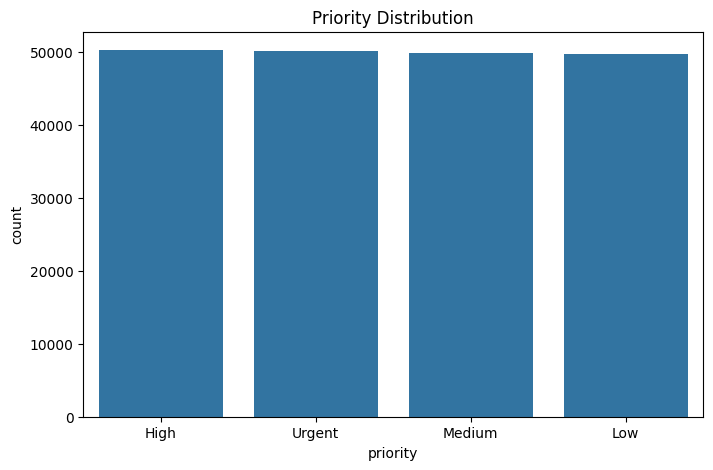

In [9]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="priority",
    order=df["priority"].value_counts().index
)

plt.title("Priority Distribution")
plt.show()

In [10]:
priority_percent = round(
    df["priority"].value_counts(normalize=True)*100,
    2
)

priority_percent

priority
High      25.12
Urgent    25.07
Medium    24.93
Low       24.88
Name: proportion, dtype: float64

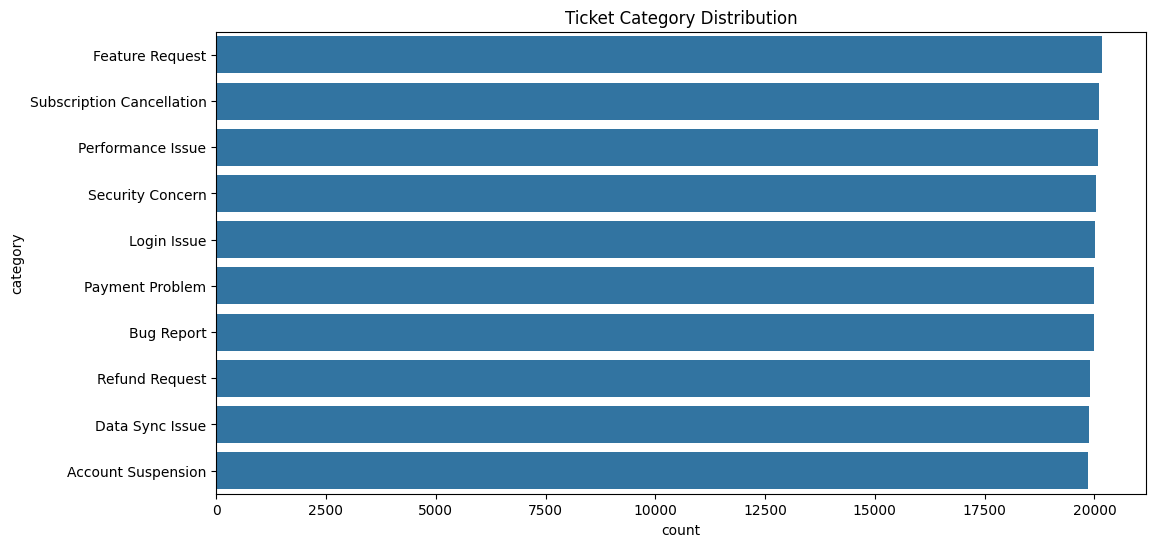

In [11]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y="category",
    order=df["category"].value_counts().index
)

plt.title("Ticket Category Distribution")

plt.show()

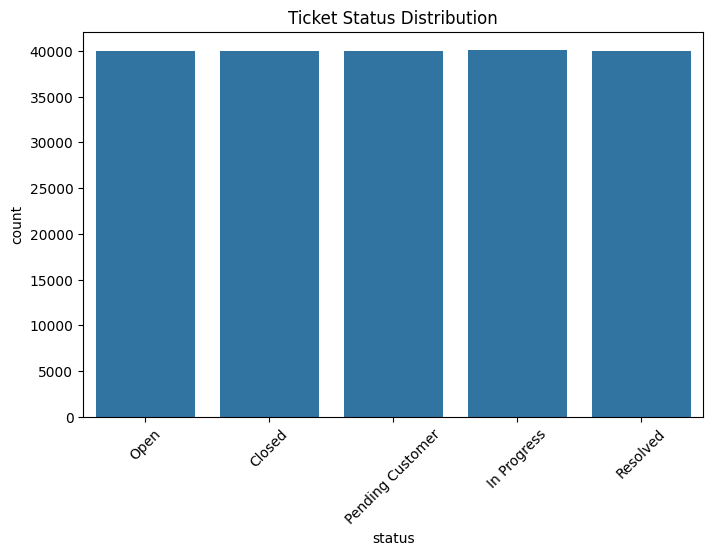

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="status"
)

plt.title("Ticket Status Distribution")

plt.xticks(rotation=45)

plt.show()

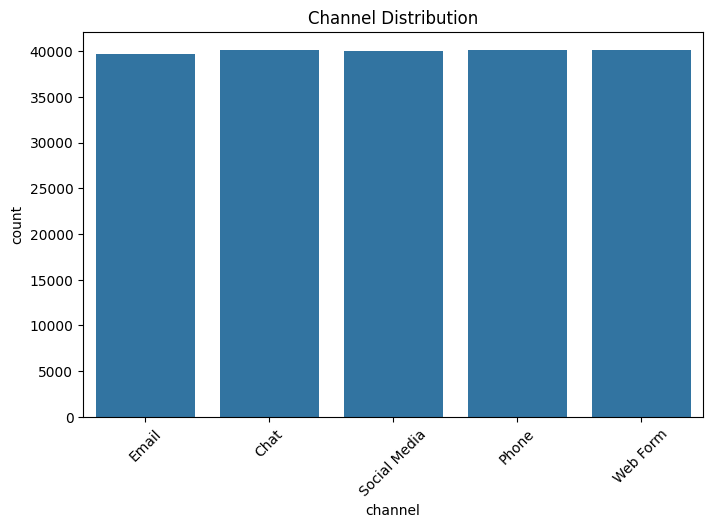

In [13]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="channel"
)

plt.title("Channel Distribution")

plt.xticks(rotation=45)

plt.show()

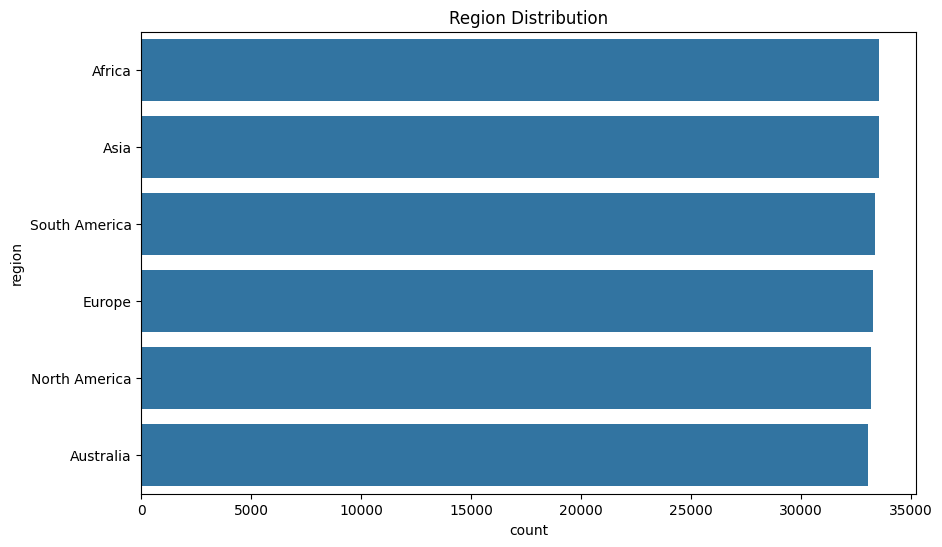

In [14]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y="region",
    order=df["region"].value_counts().index
)

plt.title("Region Distribution")

plt.show()

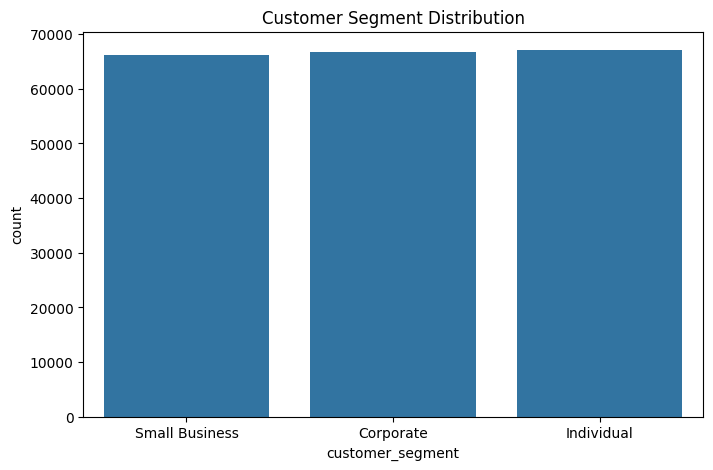

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="customer_segment"
)

plt.title("Customer Segment Distribution")

plt.show()

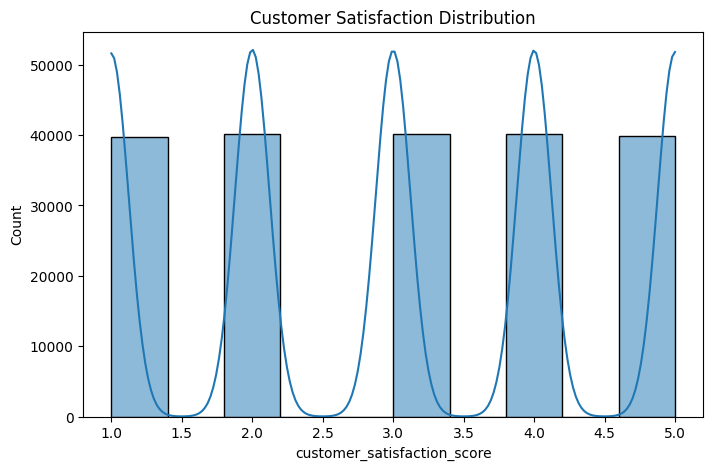

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["customer_satisfaction_score"],
    bins=10,
    kde=True
)

plt.title("Customer Satisfaction Distribution")

plt.show()

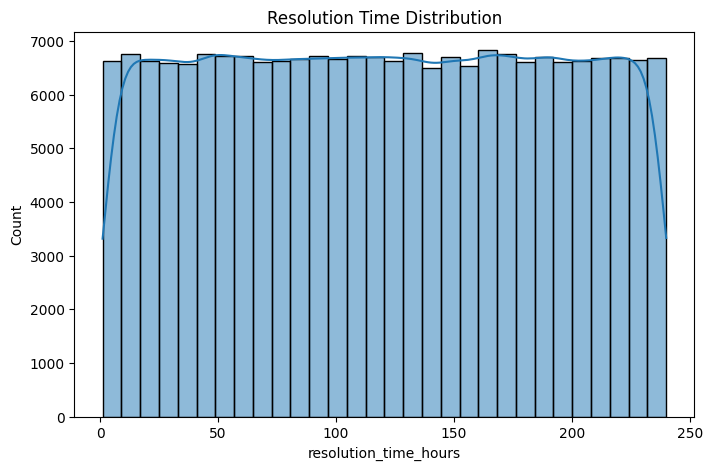

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["resolution_time_hours"],
    bins=30,
    kde=True
)

plt.title("Resolution Time Distribution")

plt.show()

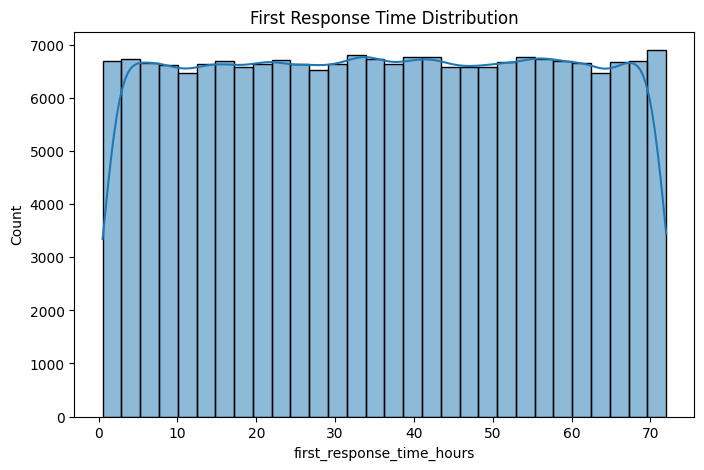

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["first_response_time_hours"],
    bins=30,
    kde=True
)

plt.title("First Response Time Distribution")

plt.show()

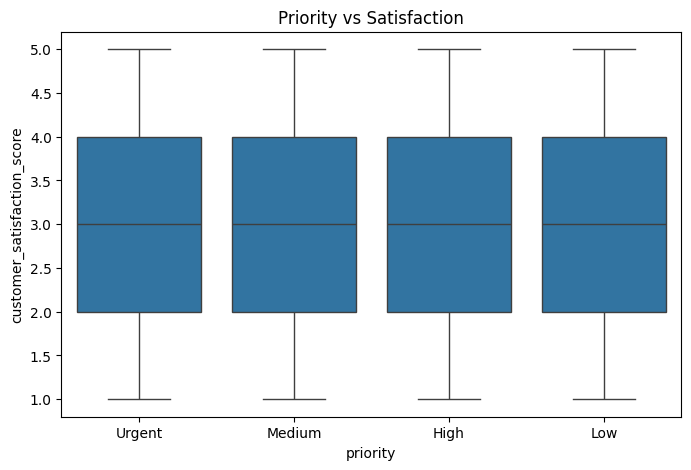

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="priority",
    y="customer_satisfaction_score"
)

plt.title("Priority vs Satisfaction")

plt.show()

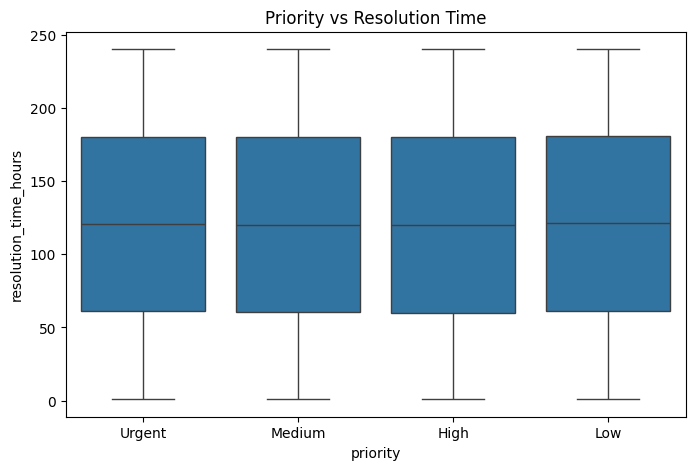

In [20]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="priority",
    y="resolution_time_hours"
)

plt.title("Priority vs Resolution Time")

plt.show()

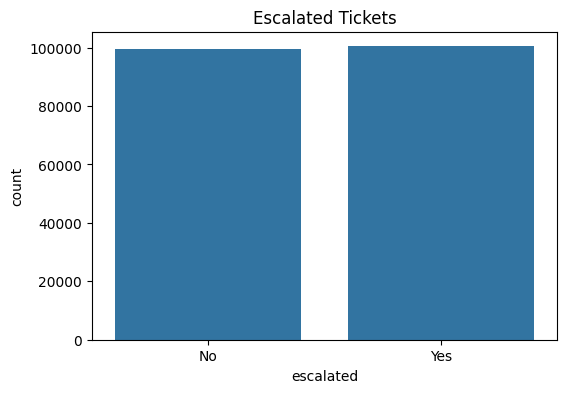

In [21]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="escalated"
)

plt.title("Escalated Tickets")

plt.show()

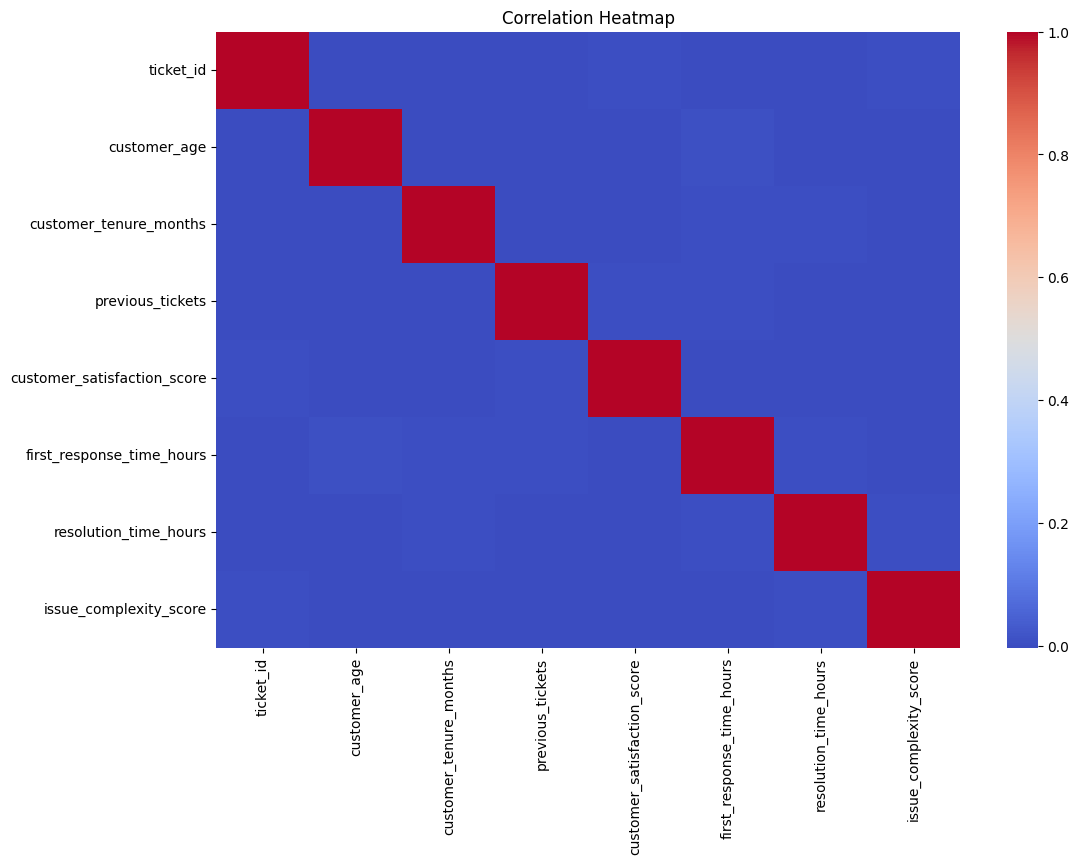

In [22]:
numeric_cols = df.select_dtypes(
    include=np.number
).columns

corr = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [23]:
df["issue_length"] = (
    df["issue_description"]
    .astype(str)
    .apply(len)
)

df["issue_length"].describe()

count    200000.000000
mean         65.923705
std           8.056100
min          55.000000
25%          56.000000
50%          68.000000
75%          72.000000
max          79.000000
Name: issue_length, dtype: float64

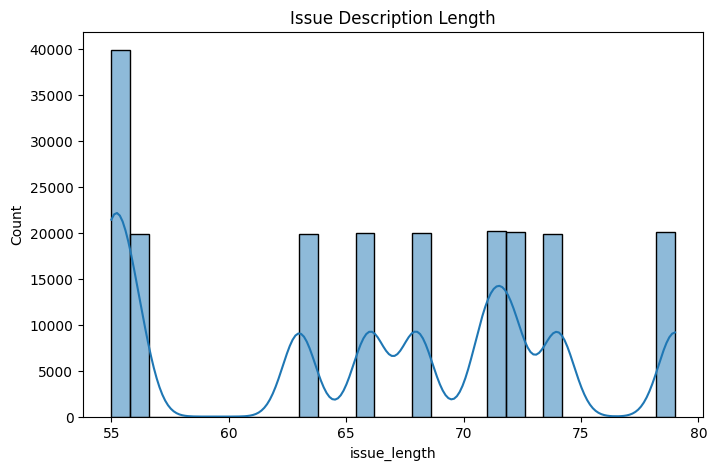

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["issue_length"],
    bins=30,
    kde=True
)

plt.title("Issue Description Length")

plt.show()

In [25]:
df["resolution_length"] = (
    df["resolution_notes"]
    .astype(str)
    .apply(len)
)

df["resolution_length"].describe()

count    200000.000000
mean         69.016975
std           6.843485
min          60.000000
25%          62.000000
50%          70.000000
75%          74.000000
max          80.000000
Name: resolution_length, dtype: float64

In [26]:
df["ticket_created_date"] = pd.to_datetime(
    df["ticket_created_date"]
)

df["ticket_resolved_date"] = pd.to_datetime(
    df["ticket_resolved_date"]
)

In [27]:
df["ticket_duration_days"] = (
    df["ticket_resolved_date"]
    - df["ticket_created_date"]
).dt.days

In [28]:
df["created_year"] = (
    df["ticket_created_date"]
    .dt.year
)

df["created_month"] = (
    df["ticket_created_date"]
    .dt.month
)

df["created_dayofweek"] = (
    df["ticket_created_date"]
    .dt.dayofweek
)

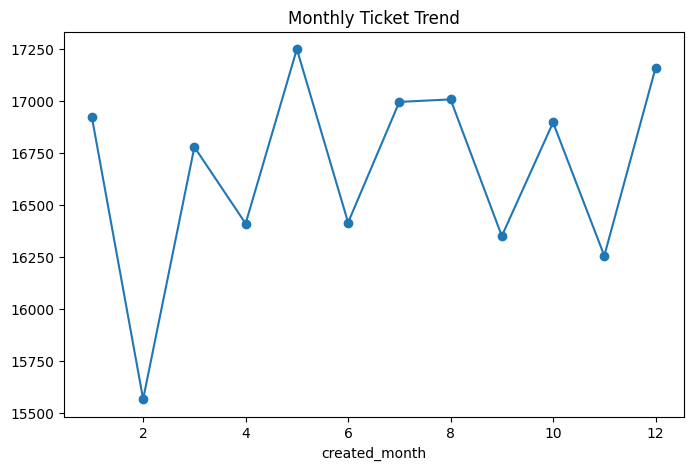

In [29]:
monthly = df.groupby(
    "created_month"
).size()

plt.figure(figsize=(8,5))

monthly.plot(marker="o")

plt.title("Monthly Ticket Trend")

plt.show()

In [30]:
missing_df = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum().values,
    "Missing Percentage":
    round(
        (df.isnull().sum()/len(df))*100,
        2
    ).values
})

missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

,Column,Missing Values,Missing Percentage
24,browser,40023,20.01
0,ticket_id,0,0.00
2,customer_email,0,0.00
1,customer_name,0,0.00
3,product,0,0.00
4,category,0,0.00
6,resolution_notes,0,0.00
5,issue_description,0,0.00
8,status,0,0.00
9,channel,0,0.00


In [31]:
print("Unique Browser Values:\n")
print(df["browser"].value_counts(dropna=False))

print("\nMissing Percentage:")
print(round(df["browser"].isnull().mean()*100,2),"%")

Unique Browser Values:

browser
Safari     40156
NaN        40023
Firefox    39983
Chrome     39972
Edge       39866
Name: count, dtype: int64

Missing Percentage:
20.01 %


In [32]:
df["browser"] = df["browser"].fillna("Unknown")

In [33]:
pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": round(
        (df.isnull().sum()/len(df))*100,
        2
    )
}).sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
ticket_id,0,0.0
customer_name,0,0.0
customer_email,0,0.0
product,0,0.0
category,0,0.0
issue_description,0,0.0
resolution_notes,0,0.0
priority,0,0.0
status,0,0.0
channel,0,0.0


In [34]:
df.to_csv(
    "Data/final_customer_support.csv",
    index=False
)